In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation

## 1.1 Loading features and labels from CSV file

In [2]:
df = pd.read_csv('features_file.csv')
df.head()

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,ST_V1_slope,ST_V1_curvature,ST_V2_slope,ST_V2_curvature,...,V4_mean,V4_std,V4_rms,V5_mean,V5_std,V5_rms,V6_mean,V6_std,V6_rms,label
0,1.868006,0.834066,1.807727,0.816168,0.438178,0.347748,-0.297693,0.047751,-0.102289,-0.007499,...,-5.921190e-18,1.0,1.0,8.881784e-18,1.0,1.0,8.881784e-18,1.0,1.0,0
1,0.763426,0.248292,-1.099139,0.258302,-1.183707,0.239575,-0.112166,0.028000,0.418905,-0.059892,...,4.440892e-18,1.0,1.0,1.480297e-18,1.0,1.0,7.401487e-18,1.0,1.0,0
2,0.894070,0.114435,0.915559,0.179301,-0.309212,0.068312,-0.192719,0.029463,-0.180877,0.086190,...,0.000000e+00,1.0,1.0,2.220446e-18,1.0,1.0,2.220446e-18,1.0,1.0,0
3,0.077744,0.274427,0.418294,0.266934,-0.113371,0.276944,0.196698,-0.064568,0.122407,-0.042827,...,-5.921190e-18,1.0,1.0,2.960595e-18,1.0,1.0,-2.960595e-18,1.0,1.0,0
4,0.655839,0.099714,0.720259,0.136851,0.309192,0.135975,0.018725,-0.004605,0.078968,-0.000704,...,2.960595e-18,1.0,1.0,-4.440892e-18,1.0,1.0,5.921190e-18,1.0,1.0,0


## 1.2 Data Understanding

Class 0: 287
Class 1: 76
Proportion: 3.78 : 1


<Axes: title={'center': 'Count (target)'}, xlabel='label'>

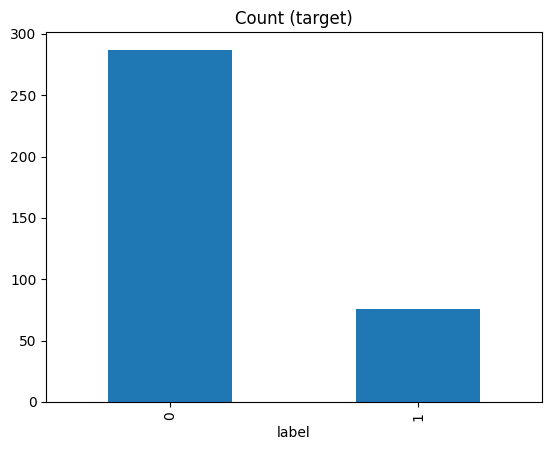

In [3]:
target_count = df.label.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')
target_count.plot(kind='bar', title='Count (target)')

In [324]:
X = df.drop(columns=["label"])
# X = df.filter(regex=r'^ST_')
y = df["label"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (363, 46)
Target shape: (363,)


In [5]:
y = (y > 0).astype(int)

In [327]:
n_negative = (y == 0).sum()
n_positive = (y > 0).sum()

print(f"negative: {n_negative} | positive: {n_positive}")

negative: 287 | positive: 76


In [7]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X.values).sum())

Missing values: 0
Infinite values: 0


In [8]:
print("Feature statistics:")
X.describe()

Feature statistics:


,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,ST_V1_slope,ST_V1_curvature,ST_V2_slope,ST_V2_curvature,...,V3_rms,V4_mean,V4_std,V4_rms,V5_mean,V5_std,V5_rms,V6_mean,V6_std,V6_rms
count,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,...,363.0,3.630000e+02,363.0,363.0,3.630000e+02,363.0,363.0,3.630000e+02,363.0,363.0
mean,0.844862,0.244682,0.732540,0.245009,0.050109,0.215371,-0.023257,-0.022652,0.043587,-0.024945,...,1.0,3.236876e-19,1.0,1.0,4.743170e-19,1.0,1.0,-5.556213e-20,1.0,1.0
std,0.709887,0.200334,0.703120,0.215139,0.589225,0.169287,0.175092,0.050703,0.162122,0.042559,...,0.0,1.081025e-17,0.0,0.0,9.702008e-18,0.0,0.0,9.232375e-18,0.0,0.0
min,-2.274943,0.033052,-1.911677,0.041640,-1.871298,0.022913,-0.484147,-0.172351,-0.550074,-0.142776,...,1.0,-2.664535e-17,1.0,1.0,-2.960595e-17,1.0,1.0,-2.812565e-17,1.0,1.0
25%,0.492817,0.116605,0.306936,0.115844,-0.336540,0.112747,-0.134209,-0.050653,-0.038564,-0.052706,...,1.0,-7.401487e-18,1.0,1.0,-5.921190e-18,1.0,1.0,-5.921190e-18,1.0,1.0
50%,0.848000,0.188771,0.694539,0.184820,0.056350,0.166724,-0.024513,-0.022640,0.047371,-0.024540,...,1.0,0.000000e+00,1.0,1.0,0.000000e+00,1.0,1.0,0.000000e+00,1.0,1.0
75%,1.192674,0.278473,1.092518,0.275195,0.444187,0.256990,0.062129,0.003715,0.132027,0.000637,...,1.0,7.401487e-18,1.0,1.0,6.661338e-18,1.0,1.0,5.921190e-18,1.0,1.0
max,3.655178,1.399592,3.223826,1.644486,3.425160,1.327069,0.674836,0.245978,0.485025,0.160187,...,1.0,2.960595e-17,1.0,1.0,3.108625e-17,1.0,1.0,2.516506e-17,1.0,1.0


In [9]:
print("Class distribution:")
print(y.value_counts())

Class distribution:
label
0    287
1     76
Name: count, dtype: int64


# 2. Model Training

In [10]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

## 2.1 Split dataset into training and testing sets

In [274]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, stratify=y,
  test_size=0.125, random_state=42  
)

In [325]:
X_train.shape

(317, 46)

In [326]:
X_test.shape

(46, 46)

## 2.2 Train the model

### Random Forest Classifier

In [277]:
rfc_model = RandomForestClassifier(
  bootstrap=False,
  class_weight='balanced_subsample',
  criterion="entropy",
  max_depth=10,
  max_features="log2",
  min_samples_leaf=8,
  min_samples_split=10,
  n_estimators=500,
  random_state=42,
  n_jobs=-1,
)

rfc_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [278]:
y_rfc_pred = rfc_model.predict(X_test)
y_rfc_prob = rfc_model.predict_log_proba(X_test)[:, 1]

threshold = 0.45  # tuning threshold
y_rfc_pred = (y_rfc_pred > threshold).astype(int)

In [279]:
print(confusion_matrix(y_test, y_rfc_pred))
print(classification_report(y_test, y_rfc_pred, target_names=['Normal', 'Brugada']))

[[27  9]
 [ 2  8]]
              precision    recall  f1-score   support

      Normal       0.93      0.75      0.83        36
     Brugada       0.47      0.80      0.59        10

    accuracy                           0.76        46
   macro avg       0.70      0.78      0.71        46
weighted avg       0.83      0.76      0.78        46



In [328]:
# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test, y_rfc_prob)

# Calculate other metrics
accuracy = accuracy_score(y_test, y_rfc_pred)
precision = precision_score(y_test, y_rfc_pred)
recall = recall_score(y_test, y_rfc_pred)
f1 = f1_score(y_test, y_rfc_pred)

# Print the metrics
print(f"AUC - ROC Score: {roc_auc:.2f}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

AUC - ROC Score: 0.88
Accuracy: 0.76
Precision: 0.47
Recall: 0.80
F1 Score: 0.59


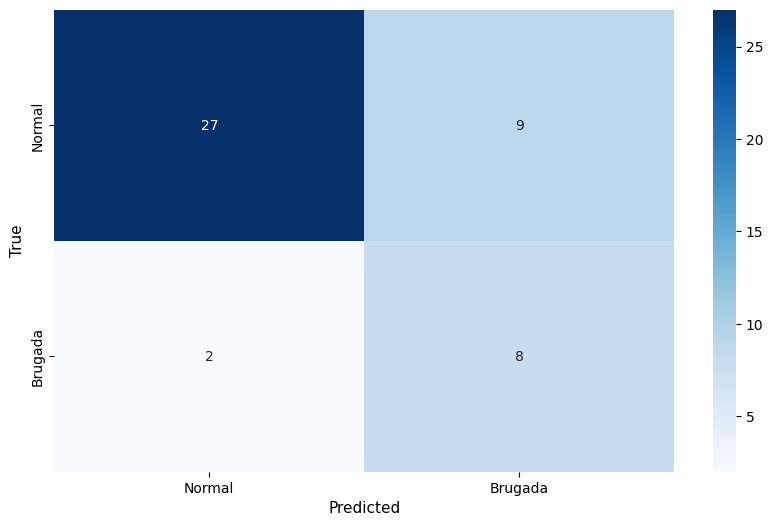

In [281]:
cm = confusion_matrix(y_test, y_rfc_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(
  cm, 
  annot=True, 
  fmt="d", 
  cmap="Blues", 
  xticklabels=["Normal", "Brugada"],
  yticklabels=["Normal", "Brugada"], 
)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.show()

### XGBoost Classifier

In [282]:
xgb_model = XGBClassifier(
  n_estimators=300,
  max_depth=6,
  learning_rate=0.05,
  subsample=0.7,
  colsample_bytree=0.8,
  min_child_weight=1,
  gamma=0.5,
  reg_alpha=0.1,
  reg_lambda=1.0,
  scale_pos_weight=n_negative / n_positive,  
  eval_metric="logloss",
  random_state=42,
  n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [298]:
y_xgb_pred = xgb_model.predict(X_test)
y_xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.5  # tuning threshold
y_xgb_pred = (y_xgb_prob > threshold).astype(int)

In [299]:
print(confusion_matrix(y_test, y_xgb_pred))
print(classification_report(y_test, y_xgb_pred, target_names=['Normal', 'Brugada']))

[[32  4]
 [ 1  9]]
              precision    recall  f1-score   support

      Normal       0.97      0.89      0.93        36
     Brugada       0.69      0.90      0.78        10

    accuracy                           0.89        46
   macro avg       0.83      0.89      0.86        46
weighted avg       0.91      0.89      0.90        46



In [329]:
# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test, y_xgb_prob)

# Calculate other metrics
accuracy = accuracy_score(y_test, y_xgb_pred)
precision = precision_score(y_test, y_xgb_pred)
recall = recall_score(y_test, y_xgb_pred)
f1 = f1_score(y_test, y_xgb_pred)

# Print the metrics
print(f"AUC - ROC Score: {roc_auc:.2f}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

AUC - ROC Score: 0.94
Accuracy: 0.89
Precision: 0.69
Recall: 0.90
F1 Score: 0.78


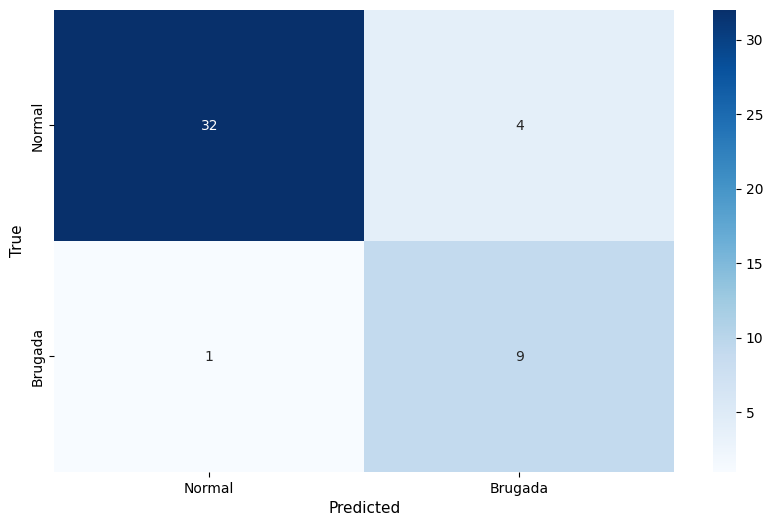

In [301]:
cm = confusion_matrix(y_test, y_xgb_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(
  cm, 
  annot=True, 
  fmt="d", 
  cmap="Blues", 
  xticklabels=["Normal", "Brugada"],
  yticklabels=["Normal", "Brugada"], 
)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.show()

## 2.3 SHAP Explanation and Visualizations

In [314]:
import shap

In [315]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.initjs()

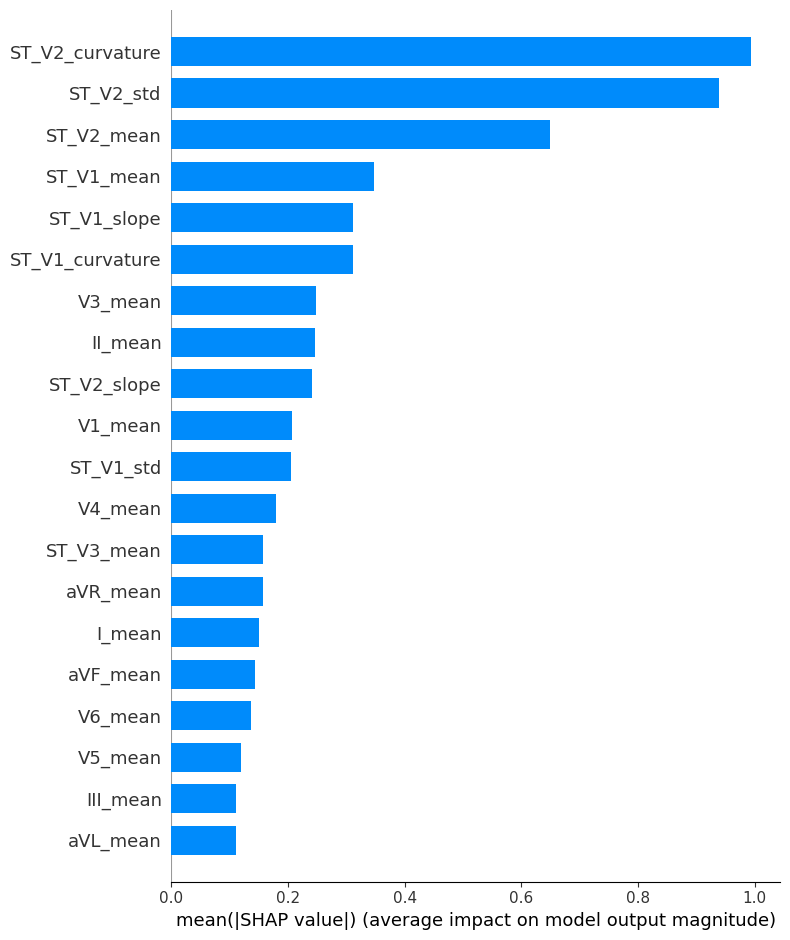

<Figure size 640x480 with 0 Axes>

In [316]:
plt.figure(figsize=(15, 20))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

plt.tight_layout()
# plt.savefig('/home/giant/Downloads/output.png')
plt.show()

In [ ]:
shap_importance = pd.DataFrame({
  'feature': X_test.columns,
  'importance': np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
  by='importance', ascending=False
)

shap_importance.head(20)

,feature,importance
9,ST_V2_curvature,0.993679
3,ST_V2_std,0.939262
2,ST_V2_mean,0.649804
0,ST_V1_mean,0.347146
6,ST_V1_slope,0.311228
7,ST_V1_curvature,0.310773
34,V3_mean,0.247787
13,II_mean,0.245353
8,ST_V2_slope,0.240976
28,V1_mean,0.207423


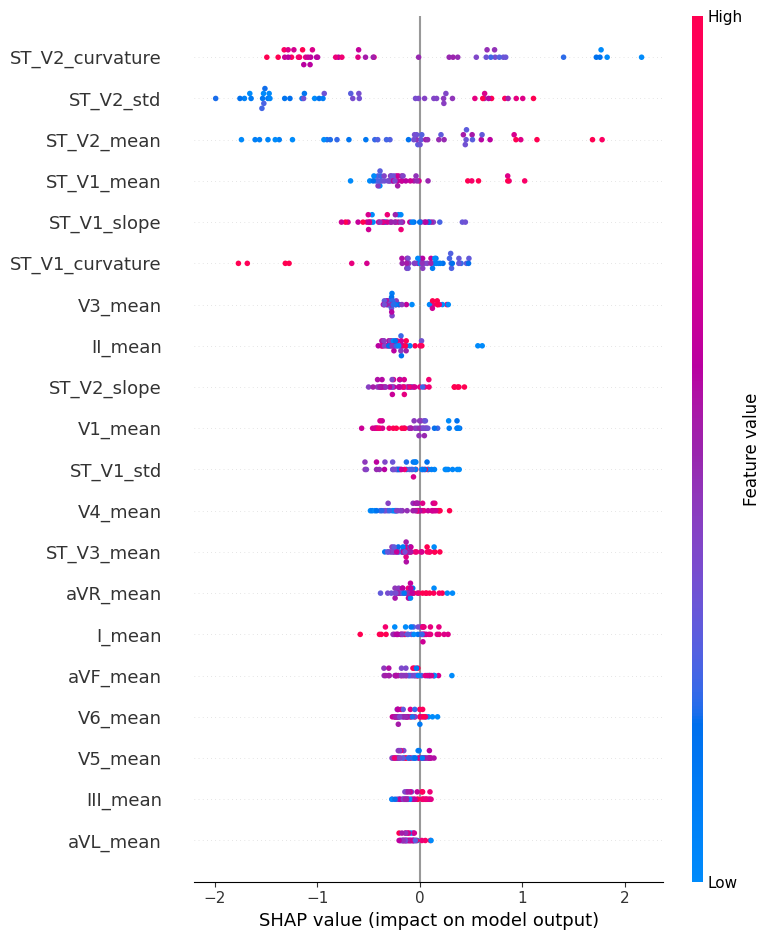

In [318]:
shap.summary_plot(shap_values, X_test)

#### Feature Importance

In [319]:
feature_names = df.drop(columns='label', axis=1).columns

In [320]:
xgb_class = xgb_model
feature_importances = xgb_class.feature_importances_ 
# feature_importances

In [321]:
df_importance = pd.DataFrame({
  'Feature': np.array(feature_names),
  'Importance': feature_importances
}).sort_values('Importance', ascending=False, ignore_index=True)

In [322]:
df_importance.head(20)

,Feature,Importance
0,ST_V2_curvature,0.083396
1,ST_V2_mean,0.083097
2,ST_V2_std,0.069575
3,ST_V1_curvature,0.055719
4,ST_V1_mean,0.052898
5,ST_V1_std,0.051857
6,ST_V3_mean,0.047641
7,V2_mean,0.046782
8,ST_V1_slope,0.043765
9,aVR_mean,0.043234


# 3. Parameter Search

In [ ]:
from sklearn.model_selection import GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
param_grid = {
  'xgb__n_estimators': [200],
  'xgb__max_depth': [6, 8],
  'xgb__learning_rate': [0.05,],
  'xgb__min_child_weight': [1, 3, 5],
  'xgb__gamma': [0, 0.5, 1],
  'xgb__subsample': [0.6, 0.8, 1.0],
  'xgb__colsample_bytree': [0.6, 0.8, 1.0],
  'xgb__reg_alpha': [0, 0.1, 1],
  'xgb__reg_lambda': [1, 5, 10],
  'xgb__scale_pos_weight': [
      n_negative / n_positive,
  ]
}

In [ ]:
grid_search = GridSearchCV(
  estimator=xgb_model,  
  param_grid=param_grid,
  scoring='roc_auc', 
  cv=skf,
  verbose=2,
  n_jobs=-1,
  return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1458 candidates, totalling 7290 fits


In [ ]:
# Extract best results
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

In [ ]:
best_params

{'xgb__colsample_bytree': 0.6,
 'xgb__gamma': 0,
 'xgb__learning_rate': 0.05,
 'xgb__max_depth': 6,
 'xgb__min_child_weight': 1,
 'xgb__n_estimators': 200,
 'xgb__reg_alpha': 0,
 'xgb__reg_lambda': 1,
 'xgb__scale_pos_weight': np.float64(3.776315789473684),
 'xgb__subsample': 0.6}

In [ ]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87        36
           1       0.53      0.80      0.64        10

    accuracy                           0.80        46
   macro avg       0.73      0.80      0.75        46
weighted avg       0.85      0.80      0.82        46



# 4. Save the model
Save the best performing model to a file for future use.

In [ ]:
import json
from datetime import datetime

tn, fp, fn, tp = confusion_matrix(y_test, y_xgb_pred).ravel()
timestamp = datetime.now().strftime("%Y-%m-%d-%H%M%S")

model_config = {
    "timestamp": timestamp,
    "model_type": "XGBClassifier",
    "threshold": threshold,
    # "features": X.columns.tolist(),
    "hyperparameters": {
        "n_estimators": xgb_model.n_estimators,
        "max_depth": xgb_model.max_depth,
        "learning_rate": xgb_model.learning_rate,
        "subsample": xgb_model.subsample,
        "colsample_bytree": xgb_model.colsample_bytree,
        "min_child_weight": xgb_model.min_child_weight,
        "gamma": xgb_model.gamma,
        "reg_alpha": xgb_model.reg_alpha,
        "reg_lambda": xgb_model.reg_lambda,
        "scale_pos_weight": xgb_model.scale_pos_weight,
        "eval_metric": xgb_model.eval_metric,
        "random_state": xgb_model.random_state,
    },
    "performance": {
        "accuracy": accuracy_score(y_test, y_xgb_pred),
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "precision": tp / (tp + fp),
        "f1_score": f1_score(y_test, y_xgb_pred),
        "roc_auc": roc_auc_score(y_test, y_xgb_pred)
    },
    "confusion_matrix": {
      "true_negatives": int(tn),
      "false_positives": int(fp),
      "false_negatives": int(fn),
      "true_positives": int(tp)
    },
    "training_data": {
        "training_samples": int(len(y_train)),
        "test_samples": int(len(y_test)),
        "feature_count": int(X.shape[1])
    },
}

with open(f"model/brugada_config_{timestamp}.json", "w") as f:
  json.dump(model_config, f, indent=4)